Import root folder as a path 

In [1]:
import sys
sys.path.append('../')

Python Packages

In [2]:
from typing import List

from models import load_model
from mydatasets import load_dataset

from pruning.heuristic_pruner import HeuristicPruner
from revival.affinity_revivor import AffinityRevivor
from core.token_manager import TokenManager

Dataset

In [3]:
datamodule = load_dataset(
    dataset_name="imagenet1k",
    data_dir="/home/Data/datasets/imagenet1k",
    batch_size=1,
    image_size=224,
)
datamodule.prepare_data()
datamodule.setup()
train_dl = datamodule.train_dataloader()

Pruner & Reviver

In [ ]:
TOKENS_PER_BLOCK = {
    0.5: {
        "stepwise": [196,196,196,98,98,98,49,49,49,25,25,25],
        "linear": [196,180,165,149,134,118,103,87,72,56,41,25],
        "exponential": [196,163,135,112,93,77,64,53,44,36,30,25],
    },
    0.6: {
        "stepwise": [196,196,196,118,118,118,71,71,71,43,43,43],
        "linear": [196,182,168,154,140,126,113,99,85,71,57,43],
        "exponential": [196,171,149,130,113,98,86,75,65,57,49,43],
    },
    0.7: {
        "stepwise": [196,196,196,137,137,137,96,96,96,67,67,67],
        "linear": [196,184,173,161,149,137,126,114,102,90,79,67],
        "exponential": [196,178,161,146,133,120,109,99,90,81,74,67],
    }
}

def get_prune_and_revive_n_tokens(budget_target, pruning_schedule, keep_ratio):
    tokens_per_block_scheme = TOKENS_PER_BLOCK[budget_target][pruning_schedule]
    n_tokens_to_prune_per_block = [round(t * keep_ratio) for t in tokens_per_block_scheme]
    n_tokens_to_revive_per_block = [t - n for t, n in zip(tokens_per_block_scheme, n_tokens_to_prune_per_block)]
    return n_tokens_to_prune_per_block, n_tokens_to_revive_per_block

In [ ]:
pruner = HeuristicPruner(criterion="C2")
revivor = AffinityRevivor(criterion="C4")
prune_n_tokens, revive_n_tokens = get_prune_and_revive_n_tokens(budget_target=0.7, pruning_schedule='exponential', keep_ratio=0.8)

token_manager = TokenManager(
    pruner=pruner,
    revivor=revivor,
    prune_ratio_or_n_tokens=prune_n_tokens,
    revive_ratio_or_n_tokens=revive_n_tokens,
)

Model

In [5]:
model = load_model(
    model_name="deit_small",
    pretrained=True,
    checkpoint_path="",
    token_manager=token_manager,
    can_tokens_revive=True,
).to("cuda")

Pesos pre-entrenados 'deit_small_patch16_224.fb_in1k' cargados desde timm


Inference over 1 sample

In [6]:
# Get one batch of data
inputs, _ = next(iter(train_dl))

# Move data to the same device as the model
device = next(model.parameters()).device
inputs = inputs.to(device)

# Forward pass through the model
stats_rows = model.forward_features_saving_stats(inputs)

Convert stats to Polars DataFrame

In [7]:
import polars as pl

df = pl.DataFrame(
    stats_rows,
    schema=["block", "attn_mask", "revived_tokens"],
    orient="row",
)

df = df.with_columns(
    [
        pl.col("attn_mask").list.slice(1).alias("attn_mask"),
        pl.col("revived_tokens").list.slice(1).alias("revived_tokens"),
    ]
)

print(df.head(5))

shape: (5, 3)
┌───────┬─────────────┬────────────────┐
│ block ┆ attn_mask   ┆ revived_tokens │
│ ---   ┆ ---         ┆ ---            │
│ i64   ┆ list[i64]   ┆ list[i64]      │
╞═══════╪═════════════╪════════════════╡
│ 0     ┆ [0, 0, … 0] ┆ [0, 0, … 0]    │
│ 1     ┆ [0, 0, … 0] ┆ [0, 0, … 0]    │
│ 2     ┆ [0, 0, … 0] ┆ [0, 0, … 0]    │
│ 3     ┆ [0, 0, … 0] ┆ [0, 0, … 0]    │
│ 4     ┆ [0, 0, … 0] ┆ [0, 0, … 0]    │
└───────┴─────────────┴────────────────┘


Build Event Matrix

In [8]:
def build_event_matrix(df: pl.DataFrame):
    event_matrix : List[List[int]] = []

    for i in range(len(df)):
        row = []
        attn_mask = df[i, 'attn_mask']
        revived_tokens = df[i, 'revived_tokens']

        for a, r in zip(attn_mask, revived_tokens):
            if not a and not r:
                row.append(0)  # Sigue vivo
            elif a and not r:
                row.append(1)  # Muerto y no revive
            elif not a and r:
                row.append(2)  # Caso imposible
            elif a and r:
                row.append(3)  # Revivido

        event_matrix.append(row)

    return event_matrix, len(event_matrix), len(event_matrix[0])

events, n_blocks, n_tokens = build_event_matrix(df)

Plot Event Matrix

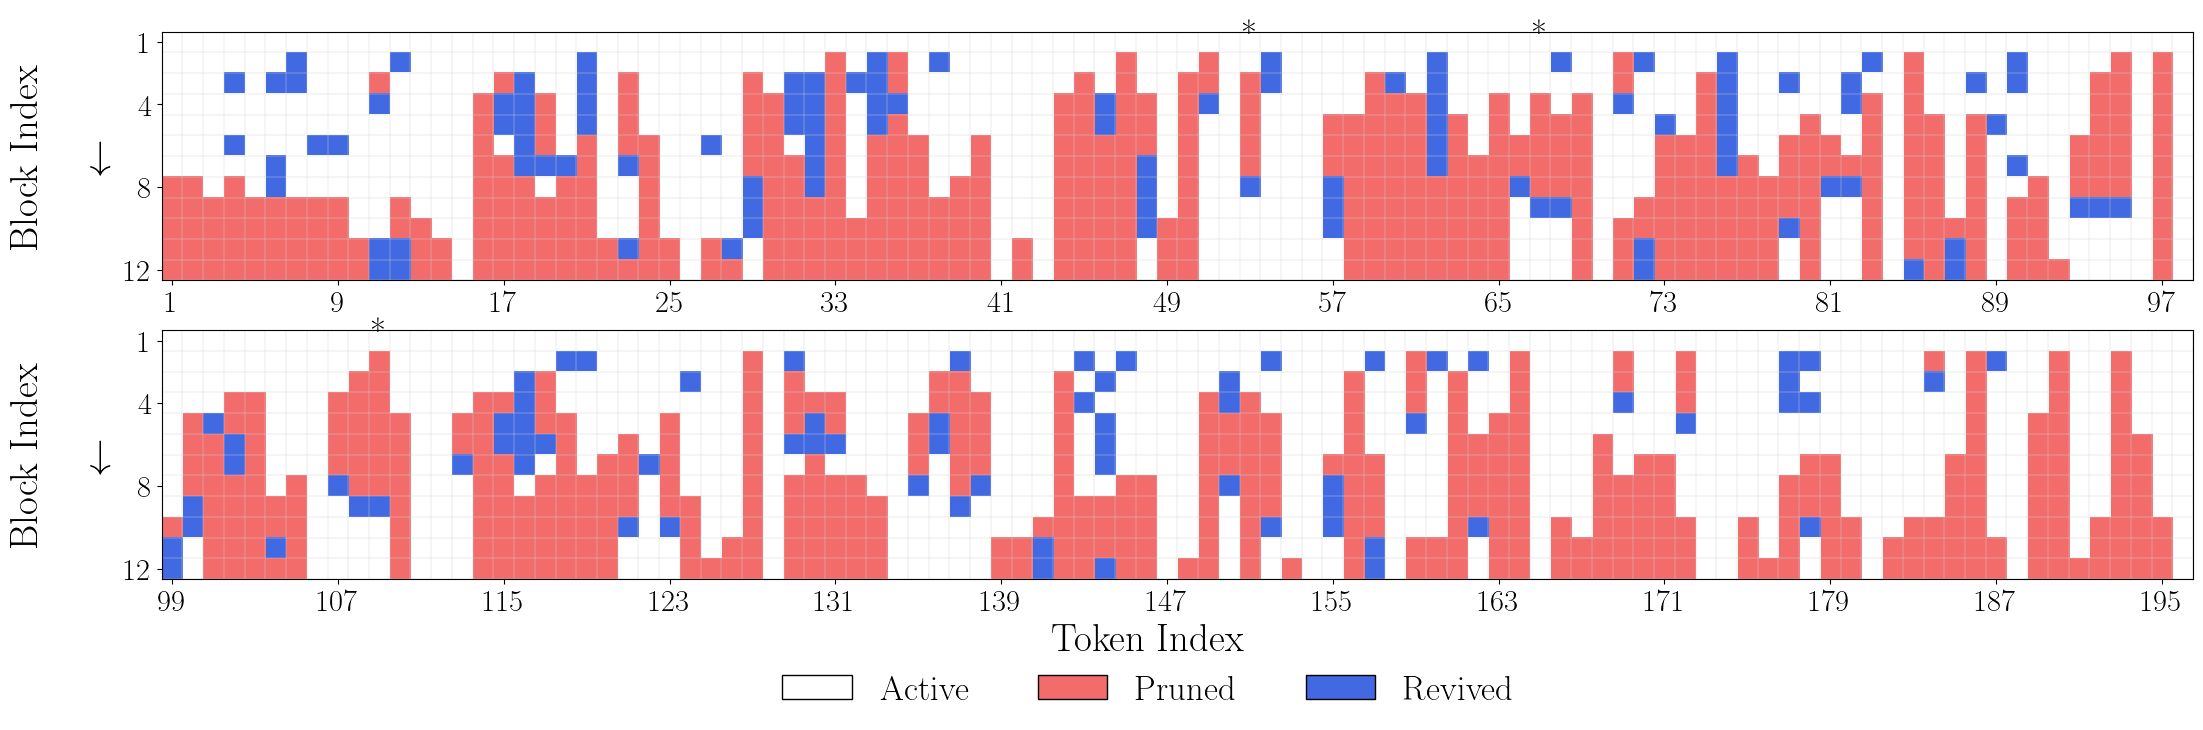

✅ Figura guardada: token_stats.pdf


In [30]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

# To LaTeX
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
})

def plot_event_matrix(event_matrix, n_blocks, n_tokens, out_path):
    """
    Paper-ready version (ICLR/CVPR style)
    Two stacked subplots (2 rows, 1 column)
    Shared X and Y labels
    """

    cmap = ListedColormap([
        "#FFFFFF",   # Active
        "#F36C6C",   # Pruned
        "#4169E1"    # Revived
    ])

    mitad = n_tokens // 2
    matrix = np.array(event_matrix)

    sub_matrices = [
        matrix[:, 0:mitad],
        matrix[:, mitad:n_tokens]
    ]

    # ---- Dynamic figure size ----
    fig_width = max(6, n_tokens * 0.15)
    fig_height = max(6, n_blocks * 0.6)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(fig_width, fig_height),
        sharey=True
    )

    for idx, ax in enumerate(axes):
        sub_matrix = sub_matrices[idx]
        n_subtokens = sub_matrix.shape[1]
        offset = 0 if idx == 0 else mitad

        ax.imshow(
            sub_matrix,
            cmap=cmap,
            aspect="equal",
            interpolation="nearest"
        )

        mark_tokens = [53, 67, 109]

        for mt in mark_tokens:
            mt0 = mt - 1  # convertir a 0-based
            if offset <= mt0 < offset + n_subtokens:
                col = mt0 - offset
                # Reemplazar el rectángulo amarillo por un asterisco centrado sobre la columna
                # Columna centrada en `col`. Posición vertical ligeramente por encima (y negativo)
                # para que quede sobre la imagen; ajustar `fontsize` según necesidad.
                ax.text(
                    col, -0.1,  # x: centro de la columna, y: un poco arriba de la imagen
                    "*",
                    color='black',
                    fontsize=25,
                    fontweight='bold',
                    ha='center',
                    va='bottom',
                    zorder=4,
                )

        # --- Dynamic ticks ---
        max_xticks = 12
        step_x = max(1, n_subtokens // max_xticks)
        xticks = np.arange(0, n_subtokens, step_x)
        ax.set_xticks(xticks)
        ax.set_xticklabels(np.arange(offset + 1, offset + n_subtokens + 1, step_x))
        ax.tick_params(axis='x', labelsize=22)

        ax.set_yticks([0, 3, 7, 11])
        ax.set_yticklabels([1, 4, 8, 12])
        ax.tick_params(axis='y', labelsize=22)

        # Subtle grid
        ax.set_xticks(np.arange(-.5, n_subtokens, 1), minor=True)
        ax.set_yticks(np.arange(-.5, n_blocks, 1), minor=True)
        ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.3)
        ax.tick_params(which="minor", bottom=False, left=False, )

        # Etiquetas de subplots
        ax.set_ylabel(f"Block Index\n\n$\leftarrow$", labelpad=0, fontsize=28)

    # Ajuste fino de márgenes
    fig.subplots_adjust(left=0.12, bottom=0.12)

    # Etiquetas globales con posición controlada
    fig.supxlabel("Token Index", y=0.01, fontsize=28)

    # ---- Shared legend ----
    legend_elements = [
        Patch(facecolor="#FFFFFF", edgecolor="black", label="Active"),
        Patch(facecolor="#F36C6C", edgecolor="black", label="Pruned"),
        Patch(facecolor="#4169E1", edgecolor="black", label="Revived"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.1),
        fontsize=25
    )

    # plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"✅ Figura guardada: {out_path}")


# Usage
out_path = "token_stats.pdf"
plot_event_matrix(events, n_blocks, n_tokens, out_path)